# Frekvensmodell for egen skade

Dette er en enkel Poisson-GLM for forventet antall egen-skader per
eksponeringsår. Notebooken bruker bare utviklingsårene 2022–2023; 2024
leses aldri.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import mean_tweedie_deviance
from sklearn.model_selection import GroupKFold

from src.glm_core import (
    cross_validate_glm,
    fit_glm,
    glm_spec,
    prepare_design_frame,
)
from src.glm_diagnostics import (
    build_coefficient_table,
    build_glm_summary,
    compare_candidate_coefficients,
    plot_glm_residuals,
)
from src.model_data import TRAIN_YEARS, build_development_frames, to_model_frame

SEED = 100
N_FOLDS = 5

## 1. Datagrunnlag

Vi avgrenser til kaskoproduktene og bygger bare utviklingsrammen. Manglende
verdier håndteres inne i hver CV-fold: median for tall og `MISSING` for
kategorier.

In [2]:
frames = build_development_frames()
development = frames["development"]

predictors = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
    "vehicle_brand_pooled",
    "seats",
]
model_columns = ["insured_id", "total_exposure", "property_claims", *predictors]
model_frame = to_model_frame(development, model_columns)
model_frame["claim_frequency"] = (
    model_frame["property_claims"] / model_frame["total_exposure"]
)

display(frames["cleaning_log"])
display(
    pd.DataFrame(
        {
            "poliseaar": [len(model_frame)],
            "eksponeringsaar": [model_frame["total_exposure"].sum()],
            "skader": [model_frame["property_claims"].sum()],
            "utviklingsaar": [", ".join(map(str, TRAIN_YEARS))],
        }
    ).round(2)
)

,step,affected_rows,result
0,"Kontroll av skjema, kategorikoder og unik poli...",0,Bestått
1,Fjerning av omkringliggende mellomrom i tekstfelt,0,Standardisert
2,Ikke-positiv power_to_weight_ratio satt til ma...,1,Standardisert
3,Manglende total- og ansvarseksponering satt ti...,1,Korrigert
4,Rader slettet eller imputert,0,Ingen


,poliseaar,eksponeringsaar,skader,utviklingsaar
0,55246,37126.01,9989,"2022, 2023"


## 2. Validering

Fem gruppefolder på `insured_id` måler hvor godt modellen generaliserer til
andre forsikrede. Samme forsikrede kan ikke ligge i både trening og
validering. Vi bruker ikke tidsfolden 2022 → 2023: den hørte til den gamle,
store kandidatstigen og brukes ikke når modellen er forhåndsdefinert.

In [3]:
group_kfold = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
cv_folds = [
    {
        "fold": f"gruppe_{number + 1}",
        "train_index": model_frame.index[train_positions],
        "val_index": model_frame.index[val_positions],
    }
    for number, (train_positions, val_positions) in enumerate(
        group_kfold.split(model_frame, groups=model_frame["insured_id"])
    )
]

## 3. Modellspesifikasjoner

For begge modeller gjelder

$$N_i \sim \operatorname{Poisson}(e_i\lambda_i), \qquad
\log \lambda_i = \beta_0 + \sum_j \beta_j x_{ij}.$$

Her er $N_i$ skadeantall og $e_i$ eksponering. Vi starter med hele den
faglig valgte kjernen og bygger deretter modellen i tre korte trinn:
splines, kjøretøyopplysninger og én produkt × alder-interaksjon.

In [4]:
CORE_PREDICTORS = [
    "policy_type",
    "year",
    "driver_age",
    "log_vehicle_value",
    "performance_hp_per_tonne",
    "fuel_type",
    "circulation_area",
    "municipality_type",
    "payment_frequency",
    "business_type",
]
frequency_settings = {
    "y": "claim_frequency",
    "data": model_frame,
    "family": sm.families.Poisson(link=sm.families.links.Log()),
    "weight": "total_exposure",
    "power": 1,
}


def build_frequency_specification(name, predictors, spline_terms=(), interaction=False):
    """Bygg én frekvensspesifikasjon; splines og interaksjon er formelledd."""
    spline_map = dict(spline_terms)
    terms = [
        f"cr({column}, df={spline_map[column]}, constraints='center')"
        if column in spline_map
        else column
        for column in predictors
    ]
    if interaction:
        terms.append("C(policy_type, Treatment('COMP_E')):driver_age")
    return glm_spec(name, terms, required_columns=predictors, **frequency_settings)

## 4. Sammenligning og valg

Poisson-deviance beregnes out-of-fold og eksponeringsvekter hver rad.
En kandidat velges bare når tre kriterier er oppfylt: lavere samlet
OOF-deviance, bedre deviance i minst fire folder og gyldig tilpasning i alle
fem folder. Dette er hele seleksjonsregelen.

In [5]:
specifications = {
    "kjernevariabler": build_frequency_specification(
        "kjernevariabler", CORE_PREDICTORS
    )
}
cv_results = {
    "kjernevariabler": cross_validate_glm(
        specifications["kjernevariabler"], model_frame, cv_folds
    )
}


def select_stage(parent_name, candidate_names):
    """Test kandidater mot én forelder med den felles treleddsregelen."""
    parent_scores = cv_results[parent_name]["scores"].set_index("fold")
    parent_oof = mean_tweedie_deviance(
        model_frame["claim_frequency"],
        cv_results[parent_name]["oof"],
        sample_weight=model_frame["total_exposure"],
        power=1,
    )
    rows = []
    for name in candidate_names:
        candidate = cv_results[name]
        is_valid = candidate["valid"] and candidate["oof"].notna().all()
        candidate_scores = candidate["scores"]
        gain = (
            parent_scores["val_deviance"]
            - candidate_scores.set_index("fold")["val_deviance"]
            if "val_deviance" in candidate_scores
            else pd.Series(dtype=float)
        )
        oof_deviance = (
            mean_tweedie_deviance(
                model_frame["claim_frequency"],
                candidate["oof"],
                sample_weight=model_frame["total_exposure"],
                power=1,
            )
            if is_valid
            else np.nan
        )
        rows.append(
            {
                "modell": name,
                "oof_deviance": oof_deviance,
                "lavere_oof": bool(is_valid and oof_deviance < parent_oof),
                "bedre_4_av_5": gain.gt(0).sum() >= 4,
                "gyldig_i_alle_folder": is_valid,
                "cv_feil": candidate["error"] or "",
            }
        )
    table = pd.DataFrame(rows).set_index("modell")
    criteria = ["lavere_oof", "bedre_4_av_5", "gyldig_i_alle_folder"]
    eligible = table.loc[table[criteria].all(axis=1)]
    selected = eligible["oof_deviance"].idxmin() if len(eligible) else parent_name
    return selected, table

### 4.1 Funksjonsform

Hver kontinuerlige kjernevariabel får én naturlig spline som utfordrer den
lineære formen. Bare den beste kvalifiserte kandidaten går videre.

In [6]:
spline_labels = {
    "driver_age": "alder_spline",
    "log_vehicle_value": "bilverdi_spline",
    "performance_hp_per_tonne": "ytelse_spline",
}
spline_candidates = {
    label: build_frequency_specification(label, CORE_PREDICTORS, [(column, 3)])
    for column, label in spline_labels.items()
}
specifications.update(spline_candidates)
cv_results.update(
    {name: cross_validate_glm(spec, model_frame, cv_folds) for name, spec in spline_candidates.items()}
)
spline_model_name, spline_selection = select_stage("kjernevariabler", list(spline_candidates))
display(spline_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
alder_spline,1.1218,True,True,True,
bilverdi_spline,1.1239,False,False,True,
ytelse_spline,1.1233,False,False,True,


### 4.2 Kjøretøyopplysninger

Bilmerke og antall seter testes hver for seg mot modellen fra
funksjonsformsteget. Ingen ekstra kriterier brukes.

In [7]:
chosen_terms = []
if spline_model_name != "kjernevariabler":
    chosen_column = next(
        column for column, label in spline_labels.items() if label == spline_model_name
    )
    chosen_terms = [(chosen_column, 3)]

vehicle_candidates = {
    "kjerne_med_bilmerke": build_frequency_specification(
        "kjerne_med_bilmerke", CORE_PREDICTORS + ["vehicle_brand_pooled"], chosen_terms
    ),
    "kjerne_med_seter": build_frequency_specification(
        "kjerne_med_seter", CORE_PREDICTORS + ["seats"], chosen_terms
    ),
}
specifications.update(vehicle_candidates)
cv_results.update(
    {name: cross_validate_glm(spec, model_frame, cv_folds) for name, spec in vehicle_candidates.items()}
)
additive_model_name, vehicle_selection = select_stage(spline_model_name, list(vehicle_candidates))
display(vehicle_selection.round(4))

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
kjerne_med_bilmerke,1.1214,True,False,True,
kjerne_med_seter,1.1217,True,True,True,


### 4.3 Produkt × alder

Én forhåndsvalgt interaksjon testes ved å legge leddet direkte til
GLM-formelen. Det er ingen egen kodevei, egne kontroller eller plott.

In [8]:
interaction_candidate = build_frequency_specification(
    "kjerne_med_produkt_alder_interaksjon",
    specifications[additive_model_name]["required_columns"],
    chosen_terms,
    interaction=True,
)
specifications[interaction_candidate["name"]] = interaction_candidate
cv_results[interaction_candidate["name"]] = cross_validate_glm(
    interaction_candidate, model_frame, cv_folds
)
selected_model_name, interaction_selection = select_stage(
    additive_model_name, [interaction_candidate["name"]]
)
display(interaction_selection.round(4))
selected_specification = specifications[selected_model_name]
print(f"Valgt frekvensmodell: {selected_model_name}")

/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


/workspaces/MotorForsikring/.venv/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil
modell,,,,,
kjerne_med_produkt_alder_interaksjon,NaN,False,True,False,gruppe_1: rangsvikt (18 av 19 kolonner); grupp...


Valgt frekvensmodell: kjerne_med_seter


### 4.4 Ablasjon

Vi prøver å fjerne én variabel om gangen fra modellen som nå er valgt. For en
kandidatvariabel $x_j$ er modellen $\log\lambda_i=\eta_i-\beta_jx_{ij}$.
En fjerning beholdes bare når den oppfyller de samme tre CV-kriteriene som
resten av stigen. Prosessen gjentas til ingen variabel kan tas bort.

In [9]:
def ablate_model(start_name, spline_terms, includes_interaction):
    """Fjern én kvalifisert variabel om gangen med den felles CV-regelen."""
    current_name = start_name
    current_predictors = specifications[start_name]["required_columns"].copy()
    removed = []
    protected = {"policy_type", "year"}
    if includes_interaction:
        protected.add("driver_age")

    while True:
        candidates = {}
        for column in current_predictors:
            if column in protected:
                continue
            name = f"{current_name}_uten_{column}"
            remaining = [item for item in current_predictors if item != column]
            terms = [item for item in spline_terms if item[0] in remaining]
            candidates[name] = build_frequency_specification(
                name, remaining, terms, includes_interaction
            )
        specifications.update(candidates)
        cv_results.update(
            {name: cross_validate_glm(spec, model_frame, cv_folds) for name, spec in candidates.items()}
        )
        next_name, table = select_stage(current_name, list(candidates))
        table["fjernet_variabel"] = [name.rsplit("_uten_", 1)[1] for name in table.index]
        display(table.round(4))
        if next_name == current_name:
            return current_name, removed
        removed.append(next_name.rsplit("_uten_", 1)[1])
        current_name = next_name
        current_predictors = specifications[current_name]["required_columns"].copy()


final_model_name, removed_predictors = ablate_model(
    selected_model_name,
    chosen_terms,
    selected_model_name == "kjerne_med_produkt_alder_interaksjon",
)
selected_specification = specifications[final_model_name]
print("Fjernet i ablasjon:", ", ".join(removed_predictors) or "ingen")

,oof_deviance,lavere_oof,bedre_4_av_5,gyldig_i_alle_folder,cv_feil,fjernet_variabel
modell,,,,,,
kjerne_med_seter_uten_driver_age,1.1237,False,False,True,,driver_age
kjerne_med_seter_uten_log_vehicle_value,1.1231,False,False,True,,log_vehicle_value
kjerne_med_seter_uten_performance_hp_per_tonne,1.1217,True,False,True,,performance_hp_per_tonne
kjerne_med_seter_uten_fuel_type,1.1226,False,False,True,,fuel_type
kjerne_med_seter_uten_circulation_area,1.1233,False,False,True,,circulation_area
kjerne_med_seter_uten_municipality_type,1.1216,True,False,True,,municipality_type
kjerne_med_seter_uten_payment_frequency,1.1235,False,False,True,,payment_frequency
kjerne_med_seter_uten_business_type,1.1264,False,False,True,,business_type
kjerne_med_seter_uten_seats,1.1218,False,False,True,,seats


Fjernet i ablasjon: ingen


## 5. Koeffisienttabell for modellen under vurdering

Den automatiske ablasjonsregelen beholdt `municipality_type`, men kandidaten
`kjerne_med_seter_uten_municipality_type` vises her før et endelig valg tas.
Koeffisientene estimeres på alle utviklingsdata og beskriver sammenhenger i
dette datasettet, ikke kausale effekter.

In [10]:
review_model_name = "kjerne_med_seter_uten_municipality_type"
assert review_model_name in specifications
review_specification = specifications[review_model_name]
final_design = prepare_design_frame(
    model_frame, model_frame, review_specification["required_columns"]
)
final_fit = fit_glm(
    review_specification,
    final_design,
    cluster_groups=final_design["insured_id"],
)
final_summary = build_glm_summary(review_specification, final_fit, final_design)
final_coefficients = build_coefficient_table(final_fit)

display(final_summary.to_frame().T.round(4))
display(final_coefficients.round(3))

,formel,familie,rader,parametere,deviance,d2,balanse
kjerne_med_seter_uten_municipality_type,"claim_frequency ~ C(policy_type, Treatment('CO...",Poisson,55246,15,1.119572,0.099495,1.0


,koeffisient,standardfeil,z,p_verdi,ki_95_lav,ki_95_høy,relativitet
Intercept,-4.685,0.569,-8.230,0.000,-5.801,-3.569,0.009
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.296,0.033,39.155,0.000,1.231,1.361,3.654
"C(year, Treatment(2023))[T.2022]",-0.083,0.036,-2.263,0.024,-0.154,-0.011,0.921
"C(fuel_type, Treatment('D'))[T.G]",-0.175,0.046,-3.771,0.000,-0.266,-0.084,0.840
"C(fuel_type, Treatment('D'))[T.MISSING]",0.008,0.139,0.055,0.956,-0.265,0.280,1.008
"C(circulation_area, Treatment('U'))[T.R]",-0.171,0.034,-5.081,0.000,-0.237,-0.105,0.843
"C(payment_frequency, Treatment('A'))[T.Q]",0.367,0.063,5.821,0.000,0.243,0.490,1.443
"C(payment_frequency, Treatment('A'))[T.S]",0.097,0.050,1.953,0.051,-0.000,0.194,1.102
"C(business_type, Treatment('NB'))[T.P]",0.304,0.036,8.461,0.000,0.233,0.374,1.355
"cr(driver_age, df=3, constraints='center')[0]",-0.387,0.130,-2.987,0.003,-0.641,-0.133,0.679


In [11]:
def summarize_candidate(name, result):
    """Samle sammenlignbare OOF-metrikker for én kandidat."""
    oof_deviance = mean_tweedie_deviance(
        model_frame["claim_frequency"],
        result["oof"],
        sample_weight=model_frame["total_exposure"],
        power=1,
    )
    scores = result["scores"]
    null_deviance = np.average(scores["val_null_deviance"], weights=scores["val_weight"])
    predicted = (result["oof"] * model_frame["total_exposure"]).sum()
    actual = model_frame["property_claims"].sum()
    return {
        "modell": name,
        "oof_deviance": oof_deviance,
        "oof_d2": 1 - oof_deviance / null_deviance,
        "oof_balanse": predicted / actual,
        "parametere": int(scores["n_params"].mean()),
    }

## 6. Stabilitet i koeffisientene

Tabellen sammenligner modellen under vurdering med de to nærmeste kandidatene
målt ved OOF-deviance. Bare koeffisienter som finnes i den endelige modellen
vises. En liten endring tyder på at estimatet er robust mot disse alternative
spesifikasjonene; den er ikke et mål på statistisk usikkerhet.

In [12]:
candidate_metrics = pd.DataFrame(
    [
        summarize_candidate(name, result)
        for name, result in cv_results.items()
        if result["valid"] and result["oof"].notna().all()
    ]
).set_index("modell")
nearest_names = [review_model_name] + [
    name
    for name in candidate_metrics.sort_values("oof_deviance").index
    if name != review_model_name
][:2]

candidate_fits = {}
for name in nearest_names:
    design = prepare_design_frame(
        model_frame, model_frame, specifications[name]["required_columns"]
    )
    candidate_fits[name] = fit_glm(specifications[name], design)

coefficient_stability = compare_candidate_coefficients(
    candidate_fits, review_model_name
)
display(coefficient_stability.round(3))

,kjerne_med_seter_uten_municipality_type,kjerne_med_bilmerke,endring_fra_kjerne_med_seter_uten_municipality_type_kjerne_med_bilmerke,kjerne_med_seter_uten_performance_hp_per_tonne,endring_fra_kjerne_med_seter_uten_municipality_type_kjerne_med_seter_uten_performance_hp_per_tonne
Intercept,-4.685,-4.068,0.617,-4.988,-0.303
"C(policy_type, Treatment('COMP_E'))[T.COMP_N]",1.296,1.290,-0.005,1.292,-0.004
"C(year, Treatment(2023))[T.2022]",-0.083,-0.083,-0.000,-0.081,0.001
"C(fuel_type, Treatment('D'))[T.G]",-0.175,-0.173,0.002,-0.152,0.023
"C(fuel_type, Treatment('D'))[T.MISSING]",0.008,-0.017,-0.025,0.025,0.017
"C(circulation_area, Treatment('U'))[T.R]",-0.171,-0.171,0.000,-0.174,-0.004
"C(payment_frequency, Treatment('A'))[T.Q]",0.367,0.374,0.007,0.366,-0.000
"C(payment_frequency, Treatment('A'))[T.S]",0.097,0.096,-0.001,0.098,0.001
"C(business_type, Treatment('NB'))[T.P]",0.304,0.303,-0.001,0.305,0.001
"cr(driver_age, df=3, constraints='center')[0]",-0.387,-0.368,0.019,-0.395,-0.007


## 7. Residualdiagnostikk

Deviance-residualen viser forskjellen mellom observert og modellert
skadefrekvens på Poisson-skalaen. Et tilfeldig mønster rundt null støtter at
den valgte modellformen fanger nivået rimelig; enkeltpunkter kan fortsatt ha
høy påvirkning ved stor eksponering.

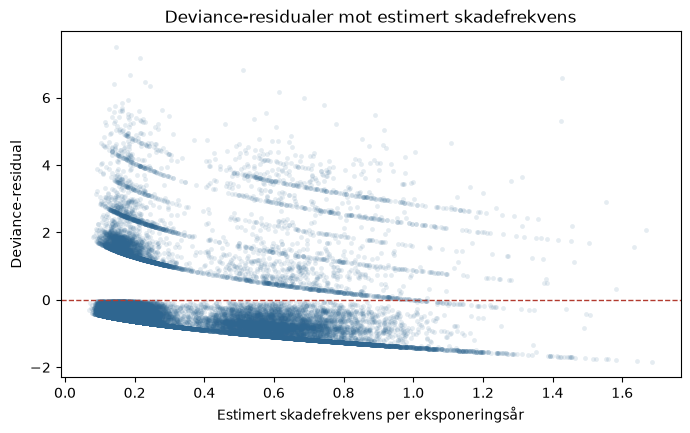

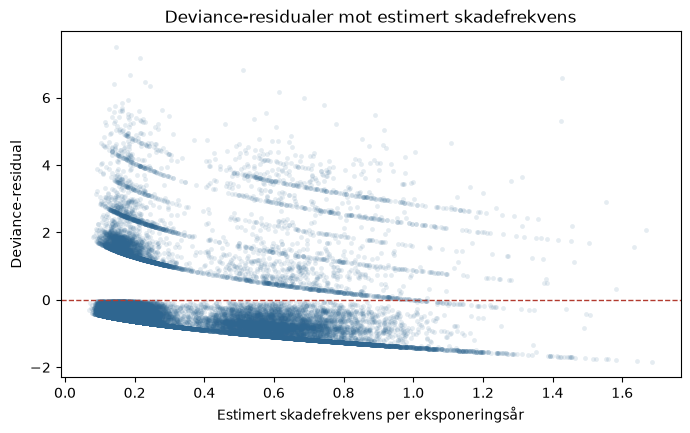

In [13]:
plot_glm_residuals(final_fit, final_design)

## 8. Beslutningstabell

Tabellen viser den valgte modellen og de to nærmeste konkurrentene på
OOF-deviance. Koeffisientene er estimert på hele utviklingssettet og er
derfor til forklaring, mens OOF-metrikkene er grunnlaget for valget.

decision_table = candidate_metrics.loc[nearest_names].copy()
decision_table.index.name = "modell"
display(decision_table.round(4))

**Begrensning.** CV-scoren er en utviklingsscore og den enkle valgregelen er
bevisst laget for presentasjon, ikke for maksimal modelloptimalisering.
Modellen må være låst før en senere, separat evaluering på 2024.

## 9. Statsmodels-sammendrag

Det innebygde sammendraget beholdes som fullstendig referanse for den valgte
modellen. Koeffisienttabellen over er den kompakte presentasjonen.

In [14]:
display(final_fit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:        claim_frequency   No. Observations:                55246
Model:                            GLM   Df Residuals:                    55231
Model Family:                 Poisson   Df Model:                           14
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -26676.
Date:                Fri, 18 Sep 2026   Deviance:                       41565.
Time:                        19:57:36   Pearson chi2:                 1.13e+05
No. Iterations:                     6   Pseudo R-squ. (CS):            0.07977
Covariance Type:              cluster                                         
=================================================================================================================
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                        -4.6851      0.569     -8.230      0.000      -5.801      -3.569
C(policy_type, Treatment('COMP_E'))[T.COMP_N]     1.2957      0.033     39.155      0.000       1.231       1.361
C(year, Treatment(2023))[T.2022]                 -0.0825      0.036     -2.263      0.024      -0.154      -0.011
C(fuel_type, Treatment('D'))[T.G]                -0.1748      0.046     -3.771      0.000      -0.266      -0.084
C(fuel_type, Treatment('D'))[T.MISSING]           0.0077      0.139      0.055      0.956      -0.265       0.280
C(circulation_area, Treatment('U'))[T.R]         -0.1707      0.034     -5.081      0.000      -0.237      -0.105
C(payment_frequency, Treatment('A'))[T.Q]         0.3666      0.063      5.821      0.000       0.243       0.490
C(payment_frequency, Treatment('A'))[T.S]         0.0969      0.050      1.953      0.051      -0.000       0.194
C(business_type, Treatment('NB'))[T.P]            0.3037      0.036      8.461      0.000       0.233       0.374
cr(driver_age, df=3, constraints='center')[0]    -0.3872      0.130     -2.987      0.003      -0.641      -0.133
cr(driver_age, df=3, constraints='center')[1]    -0.0843      0.065     -1.289      0.197      -0.212       0.044
cr(driver_age, df=3, constraints='center')[2]     0.4336      0.182      2.381      0.017       0.077       0.791
log_vehicle_value                                 0.2910      0.064      4.570      0.000       0.166       0.416
performance_hp_per_tonne                          0.0012      0.001      0.968      0.333      -0.001       0.004
seats                                            -0.0258      0.021     -1.219      0.223      -0.067       0.016
=================================================================================================================
"""